In [44]:
import numpy as np
import pandas as pd
import os
import sys
import glob
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
from transformers import AutoModelForSequenceClassification, AutoTokenizer

In [45]:
sentence_length = 6

## Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

In [46]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/stoxx_600"
dataset_path = "data/datasets/reports_subset_from_full_data_3"

In [47]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [48]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_0_1__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_1_0__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

294

In [49]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")
nace_classes.head()

,Symbol,Name,Company is Active,Company Founded Date,Country of Primary Listing Iso3,CUSIP,Date Of First Trade,Entity Country HQ,Entity Credit Parent,NACE,...,ISIN,Primary Equity Listing,Proper Name,Public Company,Region Ticker,Sec is Primary Issue,Sec Type,SEDOL,NACE_Letter,Report
0,CA05335P1099,Auxly Cannabis Group Inc.,1,1987.0,CAN,05335P109,19960301.0,CAN,003V9K-E,1.30,...,CA05335P1099,BDGMQB,Auxly Cannabis Group Inc.,1.0,XLY-CA,1,SHARE,BDGMQB3,A,Auxly Cannabis Group Inc.2.pdf
1,JP3947800003,"MEGMILK SNOW BRAND Co., Ltd.",1,2009.0,JPN,J41966102,20220727.0,JPN,0833Y1-E,1.41,...,JP3947800003,B3ZC07,"MEGMILK SNOW BRAND Co., Ltd.",1.0,MMSBF-US,0,SHARE,BKQN701,A,"MEGMILK SNOW BRAND Co., Ltd.2.pdf"
2,ID1000167901,PT Cilacap Samudera Fishing Industry Tbk,0,1999.0,IDN,Y129H6108,20220527.0,IDN,@NA,3.12,...,ID1000167901,BMBMZG,PT Cilacap Samudera Fishing Industry Tbk,1.0,ASHA-ID,0,SHARE,BMBMZG9,A,PT Cilacap Samudera Fishing Industry Tbk3.pdf
3,JP3843250006,Hokuto Corporation,1,1964.0,JPN,J2224T102,19941202.0,JPN,05HY7N-E,1.30,...,JP3843250006,643271,Hokuto Corporation,1.0,1379-JP,1,SHARE,6432715,A,Hokuto Corporation1.pdf
4,VN000000VTQ6,Viet Trung Quang Binh Joint Stock Co,0,1961.0,VNM,Y937XS108,NaN,VNM,@NA,2.30,...,VN000000VTQ6,BMCR2W,Viet Trung Quang Binh Joint Stock Co,1.0,VTQ-VN,0,SHARE,BMCR2W8,A,Viet Trung Quang Binh Joint Stock Co3.pdf


In [50]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

834

In [51]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

485

In [52]:
def get_tables(lines: list): 
    tables = []
    current_table = []

    for line in lines:
        if line.strip().startswith("|"):  # line belongs to a table
            current_table.append(line.strip())
        else:
            if current_table:  # table ended
                tables.append("\n".join(current_table))
                current_table = []

    # catch last table if file ends without empty lines
    if current_table:
        tables.append("\n".join(current_table))

    return tables

def preprocess_report(pdf_path: str) -> List[str]:

    with open(pdf_path, "r") as f: 
        text = f.read()
    
    lines = text.split("\n")

    tables = get_tables(lines)

    # drop if condidtion is True
    conditions = [
        # filter images
        lambda line: line == '<!-- image -->',
        
        #filter tables 
        lambda line: (line[0] == "|" and line[-1] == "|") if len(line) > 1 else False, 

        # filter headers
        lambda line: line.strip()[0] == "#" if len(line) > 0 else True,

        # filter sentences
        lambda line: "." not in line,
        
        # more than 50% is numbers
        lambda line: sum(ch.isalpha() for ch in line) / len(line) < 0.5,

        # minimum 3 words 
        lambda line: len(re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", '', line).strip().split(" ")) < 3,

        # Minimum 2 Sentences
        #lambda line: sum([0 if len(sentence.split(" ")) < 3 else 1 for sentence in split_text_into_sentences(line, "en")]) < 2

    ]
    accepted_lines = [line for line in lines if not any(condition(line) for condition in conditions)]
    accepted_lines += tables

    chunks = []

    for line in accepted_lines: 
        sentences = split_text_into_sentences(line, language='en')
        sentences = [sentence.strip() for sentence in sentences]
        sentences = [sentence for sentence in sentences if sentence != ""]
        new_chunks = [(" ".join(sentences[i:i+sentence_length])).strip() for i in range(0, len(sentences), 3)]

        chunks += new_chunks

    # if there is only one sentence in the last chunk, balance the two last chunks
    if len(split_text_into_sentences(chunks[-1], language = "en")) == 1: 
        last_two_chunks = chunks[-2] + " " + chunks[-1]
        chunks[-2] = last_two_chunks[0:(len(last_two_chunks) + 1) // 2]
        chunks[-1] = last_two_chunks[(len(last_two_chunks) + 1) // 2: (len(last_two_chunks)) - (len(last_two_chunks) + 1) // 2]

    chunks = [re.sub(r'\b\d+\.\d+\b', '', chunk) for chunk in chunks]
    chunks = [re.sub(r"[^a-zA-ZäöüÄÖÜß.\s]", '', chunk) for chunk in chunks]
    chunks = [re.sub(r"\s+", " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'\.{2,}', " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'^\d+\.\s*', " ", chunk) for chunk in chunks]
    chunks = [chunk.lower() for chunk in chunks]
    chunks = [chunk.strip() for chunk in chunks]

    return chunks

In [53]:
# ckpt = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
# ckpt = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
# model = classification_report_BERT.load_custom_bert_from_checkpoint(ckpt_path=ckpt)
# tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [54]:
import numpy as np
import pandas as pd

# assume df is your dataframe
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [55]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:
    
    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [56]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:

    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [57]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:

    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [58]:
#reports_results = ['../../results/BERT_classification/test_1/Heritage Foods Limited1.txt/Heritage Foods Limited1.txt_classifications.csv']

In [59]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def top3_acc(position_levels): 
    return np.mean(position_levels < 3)

In [60]:
confidence_weighted_voting.__name__

'confidence_weighted_voting'

In [61]:
reports_results

['results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Danone SA1.txt/Danone SA1.txt_classifications.csv',
 'results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Daiseki Co., Ltd.1.txt/Daiseki Co., Ltd.1.txt_classifications.csv',
 'results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Aucnet, Inc.1.txt/Aucnet, Inc.1.txt_classifications.csv',
 'results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Mennica Skarbowa SA1.txt/Mennica Skarbowa SA1.txt_classifications.csv',
 'results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Body & Mind Inc.1.txt/Body & Mind Inc.1.txt_classifications.csv',
 'results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1/Best Buy Co.

In [62]:
for agg_func in [majority_vote, confidence_weighted_voting, logit_stacking]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")

    for conf in [0.9]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm((reports_results)): 
        #for results_path in ((reports_results)): 

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            scores = df_eval.columns.drop("Sentences")
            df_softmax = df_eval[scores].apply(softmax, axis=1)
            class_eval_dict = agg_func(
                df_softmax, scores, threshold=conf
            )

            # # get label of the report
            label = report_to_nace_class.get(os.path.basename(results_path).replace("_classifications.csv", ""))
            
            try: 
                if isinstance(label, float) or isinstance(label, int):                     
                    if len(str(label).split(".")[0]) == 1: 
                        label = "0" + str(label) 

                label_description = df_nace_codes_descriptions[df_nace_codes_descriptions["CODE"] == str(label)]["NAME"].iloc[0]
                evaluation = test_base.get_evaluation(class_eval_dict, label, df_nace_codes_descriptions, level)
            except IndexError: 
                print(label, "index_error")
                label_description = ""
                evaluation = {}
            recording.append({"name": os.path.basename(results_path), "NACE": label, "label_description": label_description, **evaluation})
            df_recording = pd.DataFrame(recording)
            #df_recording.to_csv(os.path.join(result_path, "recordings.csv"))

        print()
        print("Treshold: ", conf)
        print("MRR: ", mean_reciprocal_rank(df_recording["position_lvl_1"].dropna()))
        print("Top3 Acc.: ", top3_acc(df_recording["position_lvl_1"].dropna()))
        df_recording = df_recording.dropna(subset=["nace_lvl_1", "first_class_1"])
        y_true = df_recording["nace_lvl_1"] 
        y_pred = df_recording["first_class_1"]
        print(classification_report(y_true, y_pred))

--------

majority_vote

--------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 294/294 [00:40<00:00,  7.20it/s]
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric


Treshold:  0.9
MRR:  0.4132735219691741
Top3 Acc.:  0.7004830917874396
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        45
           B       0.00      0.00      0.00        49
           C       0.00      0.00      0.00        50
           D       1.00      0.02      0.04        44
           E       1.00      0.03      0.05        38
           F       0.00      0.00      0.00        47
           G       0.07      0.95      0.13        21

    accuracy                           0.07       294
   macro avg       0.30      0.14      0.03       294
weighted avg       0.28      0.07      0.02       294

--------

confidence_weighted_voting

--------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 294/294 [00:40<00:00,  7.28it/s]
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric


Treshold:  0.9
MRR:  0.4121063987006016
Top3 Acc.:  0.7053140096618358
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        45
           B       0.00      0.00      0.00        49
           C       0.00      0.00      0.00        50
           D       0.00      0.00      0.00        44
           E       1.00      0.03      0.05        38
           F       0.00      0.00      0.00        47
           G       0.07      1.00      0.13        21

    accuracy                           0.07       294
   macro avg       0.15      0.15      0.03       294
weighted avg       0.13      0.07      0.02       294

--------

logit_stacking

--------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 294/294 [00:41<00:00,  7.12it/s]


Treshold:  0.9
MRR:  0.33153301724730294
Top3 Acc.:  0.4931972789115646
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        45
           B       0.00      0.00      0.00        49
           C       0.00      0.00      0.00        50
           D       0.00      0.00      0.00        44
           E       1.00      0.03      0.05        38
           F       0.00      0.00      0.00        47
           G       0.07      1.00      0.13        21

    accuracy                           0.07       294
   macro avg       0.15      0.15      0.03       294
weighted avg       0.13      0.07      0.02       294




/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: Undefi

In [63]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,Danone SA1.txt_classifications.csv,10.51,Operation of dairies and cheese making,C,3,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,"Daiseki Co., Ltd.1.txt_classifications.csv",38.11,Collection of non-hazardous waste,E,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
2,"Aucnet, Inc.1.txt_classifications.csv",47.91,Retail sale via mail order houses or via Internet,G,0,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
3,Mennica Skarbowa SA1.txt_classifications.csv,47.77,Retail sale of watches and jewellery in specia...,G,0,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
4,Body & Mind Inc.1.txt_classifications.csv,01.3,Plant propagation,A,14,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
...,...,...,...,...,...,...,...,...
289,SIMEC Atlantis Energy Ltd.1.txt_classification...,35.11,Production of electricity,D,2,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
290,Kahawatte Plantations PLC1.txt_classifications...,01.61,Support activities for crop production,A,2,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
291,Seche Environnement SA2.txt_classifications.csv,38.11,Collection of non-hazardous waste,E,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
292,Standard Lithium Ltd.1.txt_classifications.csv,08.91,Mining of chemical and fertiliser minerals,B,5,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G


In [64]:
report_to_nace_class

{'Auxly Cannabis Group Inc.2.txt': 1.3,
 'MEGMILK SNOW BRAND Co., Ltd.2.txt': 1.41,
 'PT Cilacap Samudera Fishing Industry Tbk3.txt': 3.12,
 'Hokuto Corporation1.txt': 1.3,
 'Viet Trung Quang Binh Joint Stock Co3.txt': 2.3,
 'Sinmah Capital Bhd2.txt': 1.47,
 'Unrivaled Brands Inc3.txt': 1.19,
 'Refined Metals Corp1.txt': 1.19,
 'TPC Plus Bhd.3.txt': 1.47,
 'Saptarishi Agro Industries Ltd.2.txt': 1.3,
 'Cresud SA1.txt': 1.61,
 'KSG Agro SA1.txt': 1.5,
 'Shandong Fengxiang Co., Ltd.1.txt': 1.47,
 'Vibe Growth Corporation3.txt': 1.3,
 'Luca, Inc.2.txt': 1.13,
 'Kahawatte Plantations PLC1.txt': 1.61,
 'R J Bio-Tech Ltd.2.txt': 1.5,
 'Cannara Biotech, Inc.1.txt': 1.3,
 'DN Agrar Group S.A1.txt': 1.41,
 'SIPEF group3.txt': 1.19,
 'Body & Mind Inc.1.txt': 1.3,
 'Clean Seas Seafood Limited2.txt': 3.21,
 'Optimi Health Corp.1.txt': 1.3,
 'Shree Ram Proteins Ltd.1.txt': 1.19,
 'SalMar ASA1.txt': 3.21,
 'Green Hygienics Holdings Inc.1.txt': 1.3,
 'Biomass Energy Project SA2.txt': 1.63,
 'Agriterr

In [65]:
df_eval = pd.read_csv(reports_results[4], index_col=0)
df_eval

,C,L,B,H,P,M,G,D,I,A,F,J,Q,NO_CLASS,K,E,Sentences
0,0.604418,1.293973,0.555527,-2.014972,1.357344,-2.854017,7.590575,0.518030,-2.204836,-5.014074,-1.272880,-3.726519,-2.786555,0.487516,-0.156681,-0.597883,california closing of seaside dispensary acqui...
1,-2.496662,-0.769658,1.748331,-1.747682,-0.671724,-1.705222,6.263223,-1.234810,-0.701737,-3.720592,6.015663,-2.769169,-2.612733,-0.522183,-0.468995,-2.225297,serves as the cfo for international private va...
2,-0.084829,1.296204,0.671468,-1.776092,0.514976,-2.632065,7.207731,0.513635,-1.703433,-4.503330,-0.403774,-3.365067,-2.803017,0.511722,-0.197864,-0.677617,the following presentation provides a general ...
3,0.308598,0.937438,0.433886,-2.039616,1.324005,-2.896639,7.738176,0.573784,-2.084994,-5.050066,-0.938849,-3.762371,-2.664824,0.310187,0.058126,-0.649138,in michigan cannabis retail stores sold us bil...
4,5.785660,1.702110,-2.485005,-1.768524,1.199746,-2.762464,5.195585,-1.860850,-3.366065,-2.344064,-4.030939,-3.572426,-2.885772,-0.180028,0.582073,0.640997,ohio new production manufacturing facility ope...
5,0.264566,1.053775,0.923461,-2.192560,1.218807,-2.851792,7.639246,0.808006,-2.184814,-5.122093,-1.028590,-3.781149,-2.717845,0.784510,-0.346465,-0.626304,licenses lowest cost method to enter a new mar...
6,-0.030666,0.604581,0.311173,-1.963914,1.302411,-2.978030,7.952580,0.556344,-1.881940,-5.140003,-0.630796,-3.823061,-2.551251,-0.002477,0.296149,-0.783508,the most comparable financial measure calculat...
7,-0.563765,0.721182,0.675702,-1.712148,0.963865,-2.652966,7.806878,0.164247,-1.426307,-4.847196,0.418347,-3.444545,-2.734670,-0.254954,0.078688,-1.261194,chartered professional accountant in canada an...
8,-2.368081,-1.405980,0.166866,-0.818628,-1.112556,-1.294712,3.969918,-1.639472,-1.143941,-2.406711,8.443926,-1.752444,-2.457677,-1.470609,-0.619488,-2.146733,over years in the financial technology amp ser...
9,-0.888045,0.415346,0.668811,-1.793819,0.663171,-2.639127,7.837833,-0.012932,-1.236283,-4.773377,0.959472,-3.454207,-2.643587,-0.149858,0.145255,-1.263080,the company does not intend and does not assum...


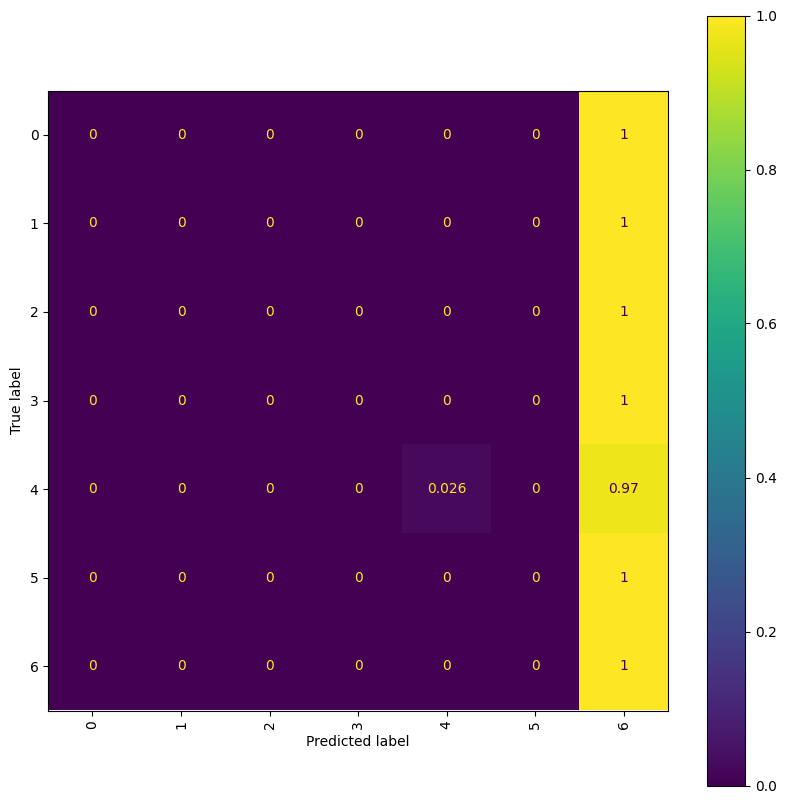

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=list(label_mapping.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()


In [67]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,Danone SA1.txt_classifications.csv,10.51,Operation of dairies and cheese making,C,3,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,"Daiseki Co., Ltd.1.txt_classifications.csv",38.11,Collection of non-hazardous waste,E,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
2,"Aucnet, Inc.1.txt_classifications.csv",47.91,Retail sale via mail order houses or via Internet,G,0,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
3,Mennica Skarbowa SA1.txt_classifications.csv,47.77,Retail sale of watches and jewellery in specia...,G,0,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
4,Body & Mind Inc.1.txt_classifications.csv,01.3,Plant propagation,A,14,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
...,...,...,...,...,...,...,...,...
289,SIMEC Atlantis Energy Ltd.1.txt_classification...,35.11,Production of electricity,D,2,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
290,Kahawatte Plantations PLC1.txt_classifications...,01.61,Support activities for crop production,A,2,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
291,Seche Environnement SA2.txt_classifications.csv,38.11,Collection of non-hazardous waste,E,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
292,Standard Lithium Ltd.1.txt_classifications.csv,08.91,Mining of chemical and fertiliser minerals,B,5,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G


In [68]:
df_eval.max()

C                                                      5.78566
L                                                     1.931382
B                                                     1.969126
H                                                    -0.818628
P                                                      2.54421
M                                                    -1.294712
G                                                      7.95258
D                                                      2.13446
I                                                    -0.391022
A                                                    -2.344064
F                                                     8.443926
J                                                    -1.752444
Q                                                    -1.331979
NO_CLASS                                              3.332962
K                                                     1.711025
E                                                     0

In [69]:
df_softmax = df_eval[scores].apply(softmax, axis=1)
df_softmax.mean(0)

C           0.027233
L           0.002657
B           0.002575
H           0.000291
P           0.003978
M           0.000144
G           0.893227
D           0.001910
I           0.000432
A           0.000042
F           0.061472
J           0.000085
Q           0.000176
NO_CLASS    0.002946
K           0.002103
E           0.000729
dtype: float64

In [70]:
df_softmax["max_class_sim"] = [scores[i] for i in np.argmax(df_softmax[scores], 1)]
df_softmax["max_sim"] = df_softmax[scores].max(1)
(df_softmax.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df_softmax)).to_dict()

{'G': 0.8782997031967708, 'F': 0.04115920598170214, 'C': 0.026084305083133683}